In [1]:
%load_ext autoreload
%autoreload 2

# Let's recommend popular items

We have 10 item categories, and user are recommended with one of them(then we can may increase to 3 items). Imagine we managed to get some insight into the items and get the most popular ones that users buy most. We don't have anything about the users nor about the items except the id. The goal is to maximize number of bought items. As we don't have historical data, let's use simulator to generate user feedback in an interactive way.

### Response Model
Users are most likely to buy the most popular items. Users buy items that are recommended to them and may buy same items in the consequent service visits.

### Task
Maximize number of bough items per user

### Data
User feedback will be generated in simulated environment and can be used for recommendation system training. For each user we have to generate 1-3 recommendation. Here we don't use information about the users or items.

### Details
From RL viewpoint, our recommendation system becomes an agent, that chooses one of the available actions(items), and have states determined by users, items, their features and previous states(interactions history). In recommendation task there are often large number of users that may have weak interactions with items, that is why we will be working with batches and recommend to and receive feedback from several users at once.


## Simulator
Simulator sim4rec was developed in Sber for user-item interaction modeling in recommendation systems. 
Below is the simulation cycle outline for training and testing.

<img src="./images/simulation_cycle.png">

For simulation there can be used real as well as synthetic data profiles(features) of users and/or items.
The usage of synthetic data contributes to securing real user data and to model more diverse scenarios in recommendation task, such as to generate more users that represent a specific group.

(1) After generating users and items we can start simulation cycle.
First we choose users to interact with the recommendation system, it can be all users or a sample of them.

(2) Then we choose items that will be available for users. We will be working with the simple setup of all users having no limits in item selection, but in real world it can be more complicated as some group of users may be restricted of accessing certain item category, or conversely it would be necessery to make more personalized recommendations. 

(3) Next recommendation system generates top-k most relevant items for each user.

(4) These items next are processed in the simulator, where user feedback is generated in the form of likes, confirmation of item being bought, time of accessing etc. For simplicity, we will be working only with one type of feedback.

(5) Given new feedback information that was received during current simulation iteration, recommendation system updates.

Next we will implement a recommendation system algorithm with which we will receive maximum number of positive feedback from users. Algorithm will be trained on N simulation cycles, and on N+1 iteration the quality of the recommendation system will be evaluated using Precision@k metric.

## Simulator and big data

Sber ecosystem has services with large amounts of client data and no less amount of items to work with. To deal with this data we will be working with PySpark that is also a building block in sim4rec.

## Imports

In [2]:
import os
import sys
os.environ["PYSPARK_PYTHON"]=sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"]=sys.executable

In [4]:
import random
import time

import pandas as pd
import numpy as np

import pyspark.sql.functions as sf
from pyspark import SparkConf
from pyspark.ml import PipelineModel
from pyspark.sql import SparkSession

from replay.models import ThompsonSampling
from replay.utils.session_handler import State
from replay.utils import get_top_k

# let's make a path for spark files and checkpoints of the simulator.
SPARK_LOCAL_DIR = './tmp/task_1'
CHECKPOINT_DIR = './tmp/task_1_checkpoints'

In [5]:
from sim4rec.modules import RealDataGenerator
from sim4rec.modules import Simulator

from PopularityResponseModel import ResponseModel
def plot_metric(metrics):
    clear_output(wait=True)
#     plt.ylim(0, max(metrics) + 1)
    plt.plot(metrics)
    plt.grid()
    plt.xlabel('iteration')
    plt.ylabel('# of clicks')
    plt.show()

def calc_metric(response_df):
    return (
            response_df
            .groupBy("user_idx").agg(sf.sum("response").alias("num_positive"))
            .select(sf.mean("num_positive")).collect()[0][0]
           )


In [ ]:
%%bash -s "$CHECKPOINT_DIR" "$SPARK_LOCAL_DIR"
# simulator writes interaction history with each user on disk
# use this if you want to restart simulation cycle, also delete previous directory and use new one - CHECKPOINT_DIR
rm -rf $1 $2

In [6]:
#set Spark session builder
NUM_THREADS = 4

spark = SparkSession.builder\
    .appName('simulator')\
    .master(f'local[{NUM_THREADS}]')\
    .config('spark.sql.shuffle.partitions', f'{NUM_THREADS * 3}')\
    .config('spark.default.parallelism', f'{NUM_THREADS * 3}')\
    .config('spark.driver.extraJavaOptions', '-XX:+UseG1GC')\
    .config('spark.executor.extraJavaOptions', '-XX:+UseG1GC')\
    .config('spark.local.dir', SPARK_LOCAL_DIR)\
    .getOrCreate()

State(spark)
spark.sparkContext.setLogLevel('ERROR')

Using Spark's default log4j profile: org/apache/spark/log4j-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
23/10/30 12:42:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
23/10/30 12:42:59 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).


In [7]:
NUM_USERS = 5000
NUM_ITEMS = 10
# number of recommendations to generated per user during each iteration
K = 1
# number of simulation cycle iterations
NUM_ITER = 20
SEED = 1234

## Original data

In [8]:
users = spark.createDataFrame([[x] for x in range(NUM_USERS)], schema=["user_idx"])
items = spark.createDataFrame([[x] for x in range(NUM_ITEMS)], schema=["item_idx"])
items.show(2)

+--------+
|item_idx|
+--------+
|       0|
|       1|
+--------+
only showing top 2 rows



Simulator let us use real user-item data as well as synthetic one, that was generated from real. 
Here we only have user and item ids, so synthetic data generation will not be relevant for us. That is why we will be using RealDataGenerator to sample from the real data.

In [9]:
item_generator = RealDataGenerator(label='items_real', seed=SEED)
user_generator = RealDataGenerator(label='users_real', seed=SEED)

item_generator.fit(items)
user_generator.fit(users)

# we will be using all users and items
item_generator.generate(NUM_ITEMS)
user_generator.generate(NUM_USERS)

DataFrame[user_idx: bigint]

# Single simulation cycle step by step

## (1) Sample users

In [10]:
# generator can sample users from the whole population. 
# Because of Spark features the sampled amount will not the exact, below will be approximately 100.
user_generator.sample(0.1).count()

504

## (2) Sample items
Each simulation cycle will work with all 10 items.

## (3) Recommendation system initialization

Here we will initialize recommendation system and use it in simulation cycle.

Model will input list of users and items and return for each user top-k most relevant items in the following dataframe format <user_idx int, item_idx int, relevance double>. 

Model can also input some additional information: pevious user-item interactions with recommendation system as well as item and user features(will not be taken on in this notebook).

We will be using Thompson Sampling model as a baseline. 

Thompson Sampling - multi-armed bandit, where the probability of the reward of each K arms is determined by beta distribution. More about this model can be found [here](https://towardsdatascience.com/thompson-sampling-fc28817eacb8).

### Baseline model

In [11]:
model = ThompsonSampling(seed=SEED)
# We have to train the model on the historical data before training it next in the cycle 
# But for simplicity we will imagine that there was only one interaction
model.fit(log=users.limit(1).crossJoin(items.limit(1)).withColumn("relevance", sf.lit(1)))

Let's see what predictions for 2 users look like: we have received 3 recommendations for each user.

In [12]:
pred = model.predict(log=None, users=users.limit(2), items=items, k=3)
pred.show(6)

+--------+--------+------------------+
|user_idx|item_idx|         relevance|
+--------+--------+------------------+
|       0|       9|0.9902115200412578|
|       0|       8|0.9902115200412578|
|       0|       7|0.9902115200412578|
|       1|       9|0.9902115200412578|
|       1|       8|0.9902115200412578|
|       1|       7|0.9902115200412578|
+--------+--------+------------------+



## (4) Response Model

Here will be used simple user-item response model, where feedback will be binary. Positive feedback probability is proportional to the popularity of the item in the past and the response model is not changed over time.

Response model inputs the dataframe in the following format <user_idx, item_idx, relevance>, where relevance is an estimate for how relevant recommendation system is and outputs the following dataframe with additional column with response information <user_idx, item_idx, relevance, response>. If some features were passed with the dataframe in the response model, they will also be returned.

In [14]:
popularity_model = ResponseModel(spark=spark, seed=SEED)

Let's see how user-item pair feedback is created using example below

In [15]:
test_response = popularity_model.transform(pred)
test_response.show()

+--------+--------+------------------+--------+
|item_idx|user_idx|         relevance|response|
+--------+--------+------------------+--------+
|       9|       0|0.9902115200412578|       0|
|       8|       0|0.9902115200412578|       0|
|       7|       0|0.9902115200412578|       0|
|       9|       1|0.9902115200412578|       0|
|       8|       1|0.9902115200412578|       1|
|       7|       1|0.9902115200412578|       0|
+--------+--------+------------------+--------+



## (5) Retraining model on additional data

After receiving responsed on recommendations model can be retrained. In the example above binary response was in the 'response' column, and the model inputs historical interactions (log) in the following dataframe format <user_idx, item_idx, relevance>, so we have to rename response column into a relevance. Note that if you want to use features for your model, it can input them as separate features during initializations or added into a log columns. 
You can implement model retraining on new data on each iteration or retrain on the whole data that is in the simulator log `sim.log`. Here we will consider training model on additional data, and in the loop below we will retrain model on all the data.

In [16]:
new_log = test_response.drop("relevance").withColumnRenamed("response", "relevance")
new_log.show()

+--------+--------+---------+
|item_idx|user_idx|relevance|
+--------+--------+---------+
|       9|       0|        0|
|       8|       0|        0|
|       7|       0|        0|
|       9|       1|        0|
|       8|       1|        1|
|       7|       1|        0|
+--------+--------+---------+



In [17]:
model.fit(log=new_log)

## (6) Model quality estimation

Quality estimation will be performed on the average amount of positive responses from users

In [18]:
calc_metric(test_response)

0.5

# Train model in the simulator

Initialize simulator and necessery models. To restart experiment, different folder `data_dir` should be used or delete previous experiment results from the disk. Experiment can also be continued from initial iteration(if it stopped on 10th iteration, it can be resumed on 11th). 

Let us run cells below step by step in order to start an experiment

In [19]:
%%bash -s "$CHECKPOINT_DIR" "$SPARK_LOCAL_DIR"
# simulator writes interaction history with each user on disk
# use this if you want to restart simulation cycle, also delete previous directory and use new one - CHECKPOINT_DIR
rm -rf $1 $2

## Reinitialize simulator components

In [20]:
user_generator.initSeedSequence(SEED)
item_generator.initSeedSequence(SEED)

sim = Simulator(
    user_gen=user_generator,
    item_gen=item_generator,
    data_dir='tmp/pipeline',
    user_key_col='user_idx',
    item_key_col='item_idx',
    spark_session=spark
)

## Model initialization

In [21]:
model = ThompsonSampling(seed=SEED)
model.fit(log=users.limit(1).crossJoin(items.limit(1)).withColumn("relevance", sf.lit(1)))

### Check correctness of the recommendation format

In [22]:
# for 10 users generate top k unique recommendations 
pred = model.predict(log=None, users=users.limit(10), items=items, k=K)

# check that recommendations were created correctly
assert pred.columns == ["user_idx", "item_idx", "relevance"]
assert pred.groupBy('user_idx').agg(sf.countDistinct("item_idx").alias("num_items")).filter(sf.col("num_items") == sf.lit(K)).count() == 10
assert pred.groupBy('user_idx').agg(sf.count("item_idx").alias("num_items")).filter(sf.col("num_items") == sf.lit(K)).count() == 10

## Response function initialization

In [23]:
popularity_model = ResponseModel(seed=SEED, spark=spark)

## Simulation cycle

In [24]:
from IPython.display import clear_output

In [25]:
# make dataframes unpersist if simulation cycles was interrupted

# current_users.unpersist()
# if log is not None:
#     log.unpersist()
# recs.unpersist()
# true_resp.unpersist()
# train_log.unpersist()

In [27]:
import matplotlib.pyplot as plt

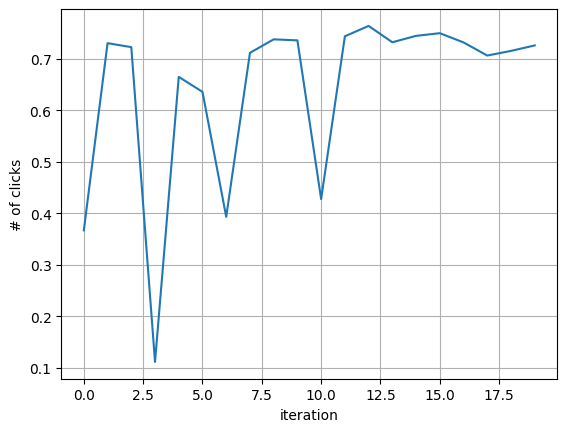

Iteration 19 finished in 1.693467617034912 sec.


In [28]:
metrics = []
for i in range(20):
    print(f'Iteration {i} started')
    iter_time = time.time()
    # sample users
    current_users = sim.sample_users(0.1).cache()
    # get logged history on user interaction in simulator
    log = sim.get_log(users)

    
    # generate top-k recommendations for each user in current_users list
    recs = model.predict(
        log=log,
        k=K,
        users=current_users,
        items=items
    ).cache()
    
    assert (recs
            .groupBy('user_idx')
            .agg(sf.count("item_idx").alias("num_items"))
            .filter(sf.col("num_items") == sf.lit(K))
            .count() 
            == 
            current_users.count()
           )
    
    # receive response/feedback on the recommended items
    true_resp = sim.sample_responses(
        recs_df=recs,
        user_features=current_users,
        item_features=items,
        action_models=popularity_model
    ).cache()

    # save user-item interactions with recommendation system on the current iteration
    sim.update_log(true_resp, iteration=i)

    # quality estimation
    metrics.append(calc_metric(true_resp))

   # Retrain recommendation model on new data
    model.item_popularity.unpersist()
    train_log = sim.log.cache()
    model.fit(
        log=train_log.select('user_idx', 'item_idx', 'response')\
                     .withColumnRenamed('response', 'relevance')
    )

    current_users.unpersist()
    if log is not None:
        log.unpersist()
    recs.unpersist()
    true_resp.unpersist()
    train_log.unpersist()

    plot_metric(metrics)
    print(f'Iteration {i} finished in {time.time() - iter_time} sec.')

Simulator logs provide information of the response model and function results

In [27]:
sim.log.filter(sf.col("__iter") == 1).show(2)

+--------+--------+-------------------+--------+------+
|item_idx|user_idx|          relevance|response|__iter|
+--------+--------+-------------------+--------+------+
|       0|       6|0.09737487011944529|       0|     1|
|       2|       9|0.20275406051254502|       1|     1|
+--------+--------+-------------------+--------+------+
only showing top 2 rows



## Final Result

In [28]:
# Let's recommend top-K items for each user in current_users list
recs = model.predict(
    k=K,
    users=current_users,
    items=items
).cache()

assert (recs
        .groupBy('user_idx')
        .agg(sf.count("item_idx").alias("num_items"))
        .filter(sf.col("num_items") == sf.lit(K))
        .count() == users.count()
       )

In [29]:
# Receive feedback on recommendations
true_resp = sim.sample_responses(
    recs_df=recs,
    user_features=users,
    item_features=items,
    action_models=popularity_model
).cache()

# Quality estimation
print(f"Average number of items bought per user = {calc_metric(true_resp)}")

Среднее число купленных товаров на пользователя после обучения модели = 0.5652


In [30]:
recs.unpersist()
true_resp.unpersist()

DataFrame[item_idx: int, user_idx: int, relevance: double, response: int]

### Let's see what model has learned

In [31]:
model.item_popularity.orderBy(sf.col('relevance').desc()).show()

+--------+--------+--------+-------------------+
|item_idx|positive|negative|          relevance|
+--------+--------+--------+-------------------+
|       2|   27500|    8680| 0.7627536122064187|
|       8|   27700|    9340| 0.7464771269686828|
|       6|   24800|    8640| 0.7400356271869556|
|       0|    8460|   11100| 0.4349407938940638|
|       3|    6980|   10760|0.39565246574131563|
|       5|    7940|   11940|  0.393665414221093|
|       9|    6880|   10960|0.38513953252522953|
|       7|     860|    5880| 0.1238704190061474|
|       4|     980|    7620|0.11569423480599778|
|       1|     320|    3460| 0.0854886003872212|
+--------+--------+--------+-------------------+



Initial values of the probability of positive feedback were as follows:

In [32]:
popularity_model.model.stages[0].pop_df.orderBy(sf.col('popularity').desc()).show()

+--------+----------+------------+----------+
|item_idx|is_popular|is_unpopular|popularity|
+--------+----------+------------+----------+
|       2|         1|           0|      0.75|
|       6|         1|           0|      0.75|
|       8|         1|           0|      0.75|
|       0|         0|           0|       0.4|
|       3|         0|           0|       0.4|
|       5|         0|           0|       0.4|
|       9|         0|           0|       0.4|
|       1|         0|           1|       0.1|
|       4|         0|           1|       0.1|
|       7|         0|           1|       0.1|
+--------+----------+------------+----------+

